### General Imports:

In [11]:
import os
import gymnasium as gym
from stable_baselines3.dqn import DQN
from stable_baselines3.dqn.policies import MlpPolicy as MLP_PPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import seaborn as sns
from netsim.gym_basic.envs import RMSA_ENV
from netsim.netSimPy import *
from sklearn import tree
from stable_baselines3.common.callbacks import EvalCallback
import numpy as np
import tensorflow as tf
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
logging.getLogger('tensorflow').setLevel(logging.FATAL)
tf.__version__
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    is_vecenv_wrapped,
)

In [2]:
def warming_lr(initial_lr=1.5e-4, max_warm_lr = 3e-4, final_lr=2e-4, warmup_progress = 0.85):
    def learning_rate_fn(progress):
        if progress >= warmup_progress:
            m = (initial_lr-max_warm_lr)/(1-warmup_progress)
            n = initial_lr - m
            return round(m*progress+n,6)
        else:
            m = (max_warm_lr-final_lr)/ warmup_progress
            return round(m*progress + final_lr,6)
    
    return learning_rate_fn

In [3]:
from typing import Union, Optional

class MyBestCallback(EvalCallback):
    def __init__(
        self,
        eval_env:RMSA_ENV,
        callback_on_new_best = None,
        callback_after_eval = None,
        n_eval_episodes: int = 5,
        eval_freq: int = 10000,
        log_path: Optional[str] = None,
        best_model_save_path: Optional[str] = None,
        deterministic: bool = True,
        render: bool = False,
        verbose: int = 1,
        warn: bool = True,
    ):
        super().__init__(
            eval_env,
            callback_on_new_best,
            callback_after_eval,
            n_eval_episodes,
            eval_freq,
            log_path,
            best_model_save_path,
            deterministic,
            render,
            verbose,
            warn
        )
        self.eval_env = eval_env
        self.best_reward_at = 0

    def _on_step(self) -> bool:
        continue_training = True

        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            # Sync training and eval env if there is VecNormalize
            if self.model.get_vec_normalize_env() is not None:
                try:
                    sync_envs_normalization(self.training_env, self.eval_env)
                except AttributeError as e:
                    raise AssertionError(
                        "Training and eval env are not wrapped the same way, "
                        "see https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html#evalcallback "
                        "and warning above."
                    ) from e

            # Reset success rate buffer
            self._is_success_buffer = []
            # self.eval_env.reset(hard_reset=True)
            episode_rewards, episode_lengths = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                render=self.render,
                deterministic=self.deterministic,
                return_episode_rewards=True,
                warn=self.warn,
                callback=self._log_success_callback,
            )

            if self.log_path is not None:
                self.evaluations_timesteps.append(self.num_timesteps)
                self.evaluations_results.append(episode_rewards)
                self.evaluations_length.append(episode_lengths)

                kwargs = {}
                # Save success log if present
                if len(self._is_success_buffer) > 0:
                    self.evaluations_successes.append(self._is_success_buffer)
                    kwargs = dict(successes=self.evaluations_successes)

                np.savez(
                    self.log_path,
                    timesteps=self.evaluations_timesteps,
                    results=self.evaluations_results,
                    ep_lengths=self.evaluations_length,
                    **kwargs,
                )

            mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)
            mean_ep_length, std_ep_length = np.mean(episode_lengths), np.std(episode_lengths)
            self.last_mean_reward = mean_reward

            if self.verbose >= 1:
                print(f"Eval num_timesteps={self.num_timesteps}, " f"episode_reward={mean_reward:.2f} +/- {std_reward:.2f}")
            # Add to current Logger
            self.logger.record("eval/mean_reward", float(mean_reward))
            self.logger.record("eval/mean_ep_length", mean_ep_length)

            if len(self._is_success_buffer) > 0:
                success_rate = np.mean(self._is_success_buffer)
                if self.verbose >= 1:
                    print(f"Success rate: {100 * success_rate:.2f}%")
                self.logger.record("eval/success_rate", success_rate)

            # Dump log so the evaluation results are printed with the correct timestep
            self.logger.record("time/total_timesteps", self.num_timesteps, exclude="tensorboard")
            self.logger.dump(self.num_timesteps)

            if mean_reward > self.best_mean_reward:
                self.best_reward_at = self.num_timesteps
                if self.best_model_save_path is not None:
                    self.model.save(os.path.join(self.best_model_save_path, "best_model"))
                self.best_mean_reward = mean_reward
                # Trigger callback on new best model, if needed
                if self.callback_on_new_best is not None:
                    continue_training = self.callback_on_new_best.on_step()
            print(
                f"Best mean reward: {self.best_mean_reward:.2f} at timestep No. {self.best_reward_at}"
            )
            clear_output(wait=True)
            # Trigger callback after every evaluation, if needed
            if self.callback is not None:
                continue_training = continue_training and self._on_event()

        return continue_training

In [13]:
from netsim.allocators import sap_ff
# FILES AND DIRECTORIES:
__file__ = 'RMSA.ipynb'
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split('.')[0]
fileDirectory = os.path.dirname(os.path.dirname(os.getcwd())) + "/notebooks/networks"
log_dir=f'./tmp/{file_name}/'
os.makedirs(log_dir, exist_ok=True)
tensorboard_log = f"./tb/{file_name}/nsfnet/"

# SIMULATION PARAMS:
# TOTAL_TIMESTEPS = int(12e6)
TOTAL_TIMESTEPS = int(4e6)
EPISODE_LENGTH = 100
N_EVALUATION_EPISODES = 80
# EVAL_FREQ = N_EVALUATION_EPISODES * EPISODE_LENGTH 
EVAL_FREQ = 50000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 5000

network = Network(
    networkFileName =  "../../../networks/nsfnet/network_c.json",
    pathsFileName= "../../../networks/nsfnet/routes.json",
    bitrateFilename= "../../../networks/nsfnet/bitrates_c_bands.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)

sim_args = dict(
    network = network,
    eventsGenerator=generator,
    # allocator=sap_ff(1)
)
simulator = NetworkSimulator(**sim_args)

env_args = dict(
    simulator = simulator,
    episode_length = EPISODE_LENGTH,
    j=5,
    n_paths=1
    # allocator=sap_ff(3)
)
env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir)

# MODEL HYPERPARAMETERS:
mArgs = dict(
    # learning_rate=warming_lr(warmup_progress = 0.95),
    # clip_range = 0.1,
    # n_steps= 2048,
    gamma=0.9,
    # ent_coef= 0.01,
    # n_epochs=23,
    # batch_size = 512,
    # ent_coef= 0.0015,
    # n_epochs=27,
    # n_steps= 1024,
    # gamma= 0.95,
    # batch_size = 16,
)
# model = PPO(MLP_PPO, env, verbose=0, seed=3, tensorboard_log=tensorboard_log, **mArgs)
model = DQN(MLP_PPO, env, verbose=0, seed=3, tensorboard_log=tensorboard_log, **mArgs)

# env.setAllocatorFunc(sap_ff)
# callback = CustomCallback(env, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVALUATION_EPISODES, verbose=0, log_path=log_dir)
eval_env:RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir+"eval_env")
# best_model_save_path = os.path.join(log_dir, "best_model")                     
callback = MyBestCallback(
    eval_env,
    n_eval_episodes=N_EVALUATION_EPISODES, 
    eval_freq=EVAL_FREQ,
    log_path=log_dir, 
    best_model_save_path=log_dir,
    verbose=1)
# train_model = model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
best_model_dir = f"../tmp/RMSA_test/best_model.zip"
expert = DQN.load(best_model_dir)

In [14]:
def generate_trajectories(n_timesteps, model, env, only_accepted = True):
    trajectories = []
    timesteps_count = 0
    state = None
    done = False
    observation, _ = env.reset()
    
    while (timesteps_count < n_timesteps):
        act, state = model.predict(
                            observation,
                            state=state,
                            episode_start=done,
                            deterministic=True,
                        )
        traj = {
            'obs': observation,
            'action': act
        }
        observation, reward, done, truncated, info = env.step(act)
        traj['reward'] = reward
        if only_accepted:
            if reward > 0:
                trajectories.append(traj)
                timesteps_count+=1
        else:
            trajectories.append(traj)
            timesteps_count+=1
        if done:
            env.reset()
    return trajectories

def flatten_trajectories(traj):
    obs = [t['obs'] for t in traj]
    acts = [t['action'] for t in traj]
    rewards = [t['reward'] for t in traj]
    return obs, acts, rewards

class MixerPolicy():
    def __init__(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta
    
    def set(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta
    
    def predict(self, observation, state, episode_start, deterministic):
        model = np.random.choice(["A", "B"], p= [self.beta, 1-self.beta])
        if model == "A":
            return self.expert.predict(observation, state, episode_start, deterministic)
        else:
            return self.student.predict([observation])[0], None

def get_expert_acts(expert, obs, env):
    acts = []
    state = None
    done = False
    env.reset()
    for o in obs:
        act, state = expert.predict(
                        o,
                        state=state,
                        episode_start=done,
                        deterministic=True,
                    )
        acts.append(act)
    return acts

def linear_beta(start, end, steps):
    def call(n):
        return max(start + n*(end-start)/(steps-1), end)
    return call




In [15]:
from sklearn import ensemble
from sklearn.linear_model import LogisticRegression
from IPython.display import clear_output
import pickle as pkl
import pandas as pd
import json

def decode_action(act, j):
        idx_path = act // j
        idx_block = act % j
        return idx_path, idx_block

def get_route_from_action(acts, j):
    return [decode_action(a, j)[0] for a in acts]


def evaluate_student(student, n_timesteps):
    traj = generate_trajectories(n_timesteps, expert, env)
    x_test = [t['obs'] for t in traj]
    y_test = [t['action'] for t in traj]
    # y_test =  get_route_from_action(y_test, env.j)
    y_pred = student.predict(x_test)

    conf_matrix = confusion_matrix(y_test, y_pred)
    score = accuracy_score(y_test, y_pred)
    print(score, conf_matrix)

def train_with_dagger(expert, env, beta_func, n_rounds, timesteps_by_round, on_round_change = None, trajes_output_name=file_name+'_trajs.csv'):
    student_policy = LogisticRegression(multi_class="multinomial")
    print(f"Starting round 1")
    print(f"Sampling new trajectories for round: {1} ")
    # clear_output(wait=True)
    obs, acts, _rewards = flatten_trajectories(generate_trajectories(timesteps_by_round, expert, env))
    
    # routes = get_route_from_action(acts, env.j)
    student_policy.fit(obs, acts)
    evaluate_student(student_policy, 100000)
    
    for r in range(1, n_rounds):
        print(f"Starting round {r+1}")
        mixer = MixerPolicy(expert, student_policy, beta = beta_func(r))
        print(f"Sampling new trajectories for round: {r+1} ")
        obs2, _acts, _rewards = flatten_trajectories(generate_trajectories(timesteps_by_round, mixer, env))
        acts2 = get_expert_acts(expert, obs2, env)
        
        # extend and update:
        shuffle = np.arange(len(obs2))
        np.random.shuffle(shuffle)
        obs2 = [obs2[s] for s in shuffle]
        acts2 = [acts2[s] for s in shuffle]
        obs.extend(obs2)
        acts.extend(acts2)

        # print(f"Saving trajectories for round: {r+1} ")
        # df = pd.DataFrame({'x':[json.dumps(o.tolist(),separators=(',', ':')) for o in obs2], 'y':acts2})
        # df.to_csv(trajes_output_name,
        #             mode="a",
        #             index=False,
        #             header=False
        #         )
        print(f"Fitting student for round: {r+1} ")
        # clear_output(wait=True)
        
        # routes = get_route_from_action(acts, env.j)
        student_policy.fit(obs, acts)
        evaluate_student(student_policy, 100000)
        
    return student_policy

In [16]:
n_steps = 3
beta_func = linear_beta(1, 0, n_steps)
student = train_with_dagger(expert, env, beta_func, n_steps,timesteps_by_round=500)

Starting round 1
Sampling new trajectories for round: 1 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


0.98015 [[97997    38     0     0]
 [ 1875    18     0     0]
 [   55     0     0     0]
 [   17     0     0     0]]
Starting round 2
Sampling new trajectories for round: 2 
Fitting student for round: 2 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


0.98214 [[98076    60     0     0]
 [ 1667   138     0     0]
 [   40     0     0     0]
 [   19     0     0     0]]
Starting round 3
Sampling new trajectories for round: 3 
Fitting student for round: 3 


/Users/jbcedeno/Documents/projcts/multiband-gymnasium/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


0.98378 [[98028    97     0     0]
 [ 1457   350     0     0]
 [   28     0     0     0]
 [   40     0     0     0]]


### Saving the agent

In [17]:
pickle_out = open("student_LGR.pkl","wb")
pkl.dump(student,pickle_out)
pickle_out.close()
# pickle_out = open("student_LGR.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

In [18]:

def get_actions_count(y_test):
    y1_test = [0]*15
    for yv in y_test:
        y1_test[yv] += 1
    return y1_test
    

In [27]:
def get_metrics(confusion_matrix):
    # Calcula métricas
    precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
    recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    specificity = np.diag(confusion_matrix) / (np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix))
    f1_score = 2 * (precision * recall) / (precision + recall)
    
    # Imprime las métricas
    for i in range(len(precision)):
        print(f"Clase {i + 1}:")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  F1-score: {f1_score[i]:.4f}")
        print(f"  Sensibilidad (Recall): {recall[i]:.4f}")
        print(f"  Especificidad: {specificity[i]:.4f}\n")

### Global accuracy

In [22]:
traj = generate_trajectories(1000, expert, env)
x_test = [t['obs'] for t in traj]
y_test = [int(t['action']) for t in traj]

# y_pred = predict(x_test,student, env)
y_pred = student.predict(x_test)
score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred,labels=[i for i in range(15)])
print(score)
print(conf_matrix)
print(f1_score(y_test,y_pred, average='weighted'))

0.987
[[985   2   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [ 10   2   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  1   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]]
0.9835295007564296


In [28]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.9890
  F1-score: 0.9934
  Sensibilidad (Recall): 0.9980
  Especificidad: 492.5000

Clase 2:
  Precision: 0.5000
  F1-score: 0.2500
  Sensibilidad (Recall): 0.1667
  Especificidad: 0.2000

Clase 3:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 4:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 6:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 7:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 8:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 9:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 10:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 11:
  Precision: nan
  F1-score

/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:3: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:4: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:5: RuntimeWarning: invalid value encountered in divide
  specificity = np.diag(confusion_matrix) / (np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix))


### Inter-path accuracy

In [29]:

n_conf_matrix = np.zeros(shape=(3,3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir//5,ic//5] += conf_matrix[ir][ic]

def score(matrix):
    total = sum(matrix.reshape(-1,1))
    correct = np.trace(matrix)
    return correct/total
s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)


1.0
[[1000.    0.    0.]
 [   0.    0.    0.]
 [   0.    0.    0.]]


In [30]:


# Matriz de confusión proporcionada
confusion_matrix = np.array(n_conf_matrix)

get_metrics(confusion_matrix)



Clase 1:
  Precision: 1.0000
  F1-score: 1.0000
  Sensibilidad (Recall): 1.0000
  Especificidad: inf

Clase 2:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 3:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:3: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:4: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:5: RuntimeWarning: divide by zero encountered in divide
  specificity = np.diag(confusion_matrix) / (np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix))
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:5: RuntimeWarning: invalid value encountered in divide
  specificity = np.diag(confusion_matrix) / (np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix))


### Inter-spectrum accuracy

In [31]:
n2_conf_matrix = np.zeros(shape=(5,5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir%5,ic%5] += conf_matrix[ir][ic]

def score(matrix):
    total = sum(matrix.reshape(-1,1))
    correct = np.trace(matrix)
    return correct/total
s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)


0.987
[[985.   2.   0.   0.   0.]
 [ 10.   2.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  1.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]]


In [32]:
# Matriz de confusión proporcionada
confusion_matrix = np.array(n2_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.9890
  F1-score: 0.9934
  Sensibilidad (Recall): 0.9980
  Especificidad: 492.5000

Clase 2:
  Precision: 0.5000
  F1-score: 0.2500
  Sensibilidad (Recall): 0.1667
  Especificidad: 0.2000

Clase 3:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan

Clase 4:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000

Clase 5:
  Precision: nan
  F1-score: nan
  Sensibilidad (Recall): nan
  Especificidad: nan



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:3: RuntimeWarning: invalid value encountered in divide
  precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:4: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_17335/3085100027.py:5: RuntimeWarning: invalid value encountered in divide
  specificity = np.diag(confusion_matrix) / (np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix))


In [33]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    observation, _ = env.reset(options={"hard_reset": True, "lambda": mLambda})
    accepted_requests = 0
    
    while (timesteps_count < n_timesteps):
        act = student.predict([observation])[0]
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests+=1
        if done:
            env.reset()
        timesteps_count+=1
    return 1 - accepted_requests/n_timesteps

def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    observation, _ = env.reset(options={"hard_reset": True, "lambda": mLambda})
    accepted_requests = 0
    
    while (timesteps_count < n_timesteps):
        act, state = expert.predict(
                            observation,
                            state=state,
                            episode_start=done,
                            deterministic=True,
                        )
        observation, reward, done, truncated, info = env.step(act)
        if reward == 1:
            accepted_requests+=1
        if done:
            env.reset()
        timesteps_count+=1
    return 1 - accepted_requests/n_timesteps



loads = [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500 ]
results = {
    "model": [],
    "student": [],
}
N_EVALUATIONS = 1000

for l in loads:
    env.reset(options={"allocator": None})
    # agent_model, _ = evaluate_policy(env, n_eval_episodes=N_EVALUATION_EPISODES, model = model, return_dataframe=False, return_episode_rewards=False, seed=1)
    bp = evaluate_expert(expert, N_EVALUATIONS, l)
    print("model",bp)
    results["model"].append(bp)
    
    bp = evaluate_bp_student(student, N_EVALUATIONS, l)
    print("student",bp)
    results["student"].append(bp)



model 0.0
student 0.0
model 0.0
student 0.0
model 0.0
student 0.0
model 0.0020000000000000018
student 0.0
model 0.0010000000000000009
student 0.0
model 0.0
student 0.0
model 0.0010000000000000009
student 0.0
model 0.0010000000000000009
student 0.0


In [34]:
loads = [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500 ]
N_EVALUATIONS = 1000
lgr_bp = []

for l in loads:
    bp = evaluate_bp_student(student, N_EVALUATIONS, l)
    lgr_bp.append(round(bp, 7) )
print(lgr_bp)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


### features importance

[-6.26746214e-02  3.35601498e-01  3.13099606e-01 -4.15391647e-01
  5.29652802e-01 -3.07703947e-01  2.66982182e-01 -1.70350162e-01
  2.47826134e-01 -2.10057153e-01 -1.38645309e-01  5.52933585e-02
  1.41483960e-01 -3.83867867e-01 -1.87637839e-01 -1.10564706e-01
 -2.98254747e-01  3.79091475e-01 -4.61550097e-01  3.98124395e-01
 -3.27654491e-01 -9.32646396e-02 -3.68902365e-02 -1.31233955e-01
  2.04666839e-01  2.09703435e-03  1.40665508e-01  7.23654293e-01
  3.26429906e-01 -2.82264880e-01  3.67124034e-02  6.97730537e-02
  1.71944598e-02  4.79516099e-01 -2.91693927e-01  6.41756349e-01
 -3.26209377e-01  5.08622566e-01 -5.07502689e-01 -3.65701320e-01
 -1.48025977e-01 -4.64246103e-01 -5.05129037e-01  1.19869332e-01
  3.74475954e-02  4.69152718e-01  1.41835587e-01  7.74784422e-01
  5.24166258e-01  7.03873778e-01  7.41726156e-01  7.42682865e-01
  1.47194130e-01  2.71418386e-01 -1.61767689e-01 -3.04768395e-01
  4.90250257e-02  2.06116428e-01 -9.45182983e-02 -2.97158596e-01
 -2.81400434e-01 -1.24181

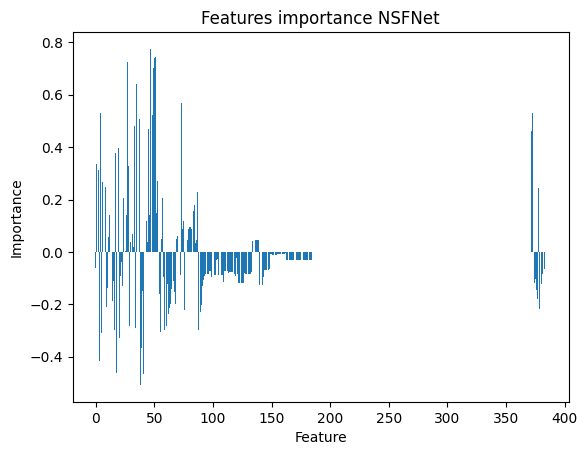

In [35]:
import pandas as pd

base_output_dir_features = f'./plots/{__file__}/features_importance_heuristic/'

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

# print("lolo",student.coef_[0])
# print("lolo",len(student.get_params()))

importances_sk = student.coef_[1]
importance = pd.DataFrame(importances_sk)
importance.to_csv(f'{output_dir}features_importance_heuristic.csv')
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + 'NSFNet.png')
plt.show()